In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("headbrain.csv")
df.shape


(237, 4)

In [3]:
df.head()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [4]:
x=df["Head Size(cm^3)"].values
y=df["Brain Weight(grams)"].values


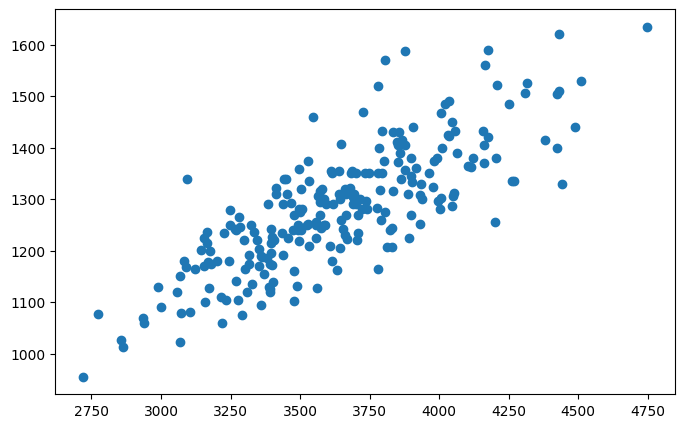

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.show()

In [6]:
n=len(x)
mean_x=np.mean(x)
mean_y=np.mean(y)
m=np.sum((x-mean_x)*(y-mean_y))/np.sum((x-mean_x)**2)
c=mean_y-(m*mean_x)
print(f"m={m}, c={c}")

m=0.2634293394893993, c=325.5734210494428


In [7]:
prediction=[]
for i in range(n):
    y_pred=m*x[i]+c
    prediction.append(int(y_pred))
print("Prediction :", prediction[:5])
print("Actual :", y[:5])



Prediction : [1514, 1310, 1448, 1320, 1425]
Actual : [1530 1297 1335 1282 1590]


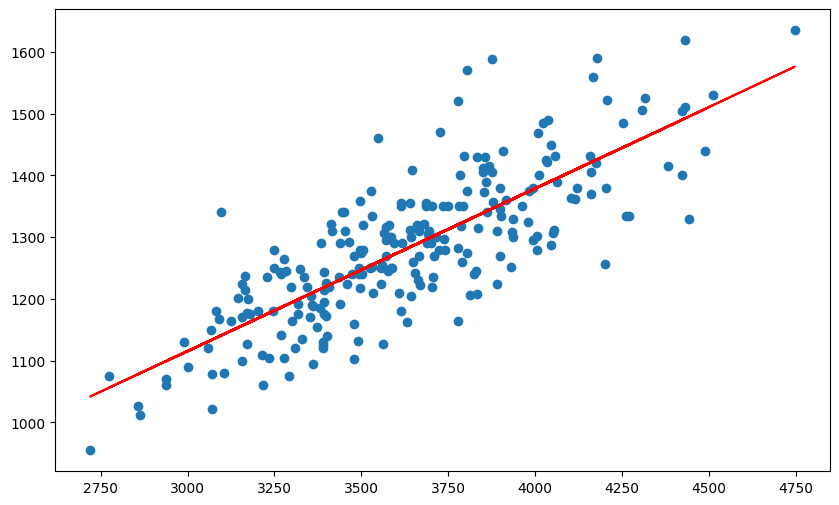

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.plot(x,prediction,color="red")
plt.show()

In [9]:
error=0
for i in range(n):
    error+=(y[i]-prediction[i])**2
mse=error/n
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))

MSE : 5202.9029535864975
RMSE : 72.13115106239812


GRADIENT DESCENT:

In [10]:
from sklearn.preprocessing import MinMaxScaler
x=np.reshape(x,(-1,1))
y=np.reshape(y,(-1,1))
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)
y_scaled=minmax.fit_transform(y)
x_scaled[:5]


array([[0.88406512],
       [0.50222003],
       [0.7602368 ],
       [0.52146029],
       [0.71879625]])

In [11]:
def gradient_descent(epochs, alpha):
    slope,inter=0,0
    for i in range(epochs):
        y_pred=slope*x_scaled+inter
        loss=y_pred-y_scaled
        gradSlope=(2/n)*np.dot(x_scaled.T,loss)
        gradInter=(2/n)*np.sum(loss)
        slope-=alpha*gradSlope #slope = slope - alpha*gradSlope
        inter-=alpha*gradInter #inter = inter - alpha*gradInter
    return slope, inter

In [12]:
epochs=8000
alpha=0.01
slope, inter=gradient_descent(epochs, alpha)
print(f"Slope : {slope}, Intercept : {inter}")

Slope : [[0.77698429]], Intercept : 0.13192040975853606


In [13]:
prediction=[]
for i in range(n):
    y_pred=slope[0][0]*x_scaled[i]+inter
    prediction.append(y_pred)

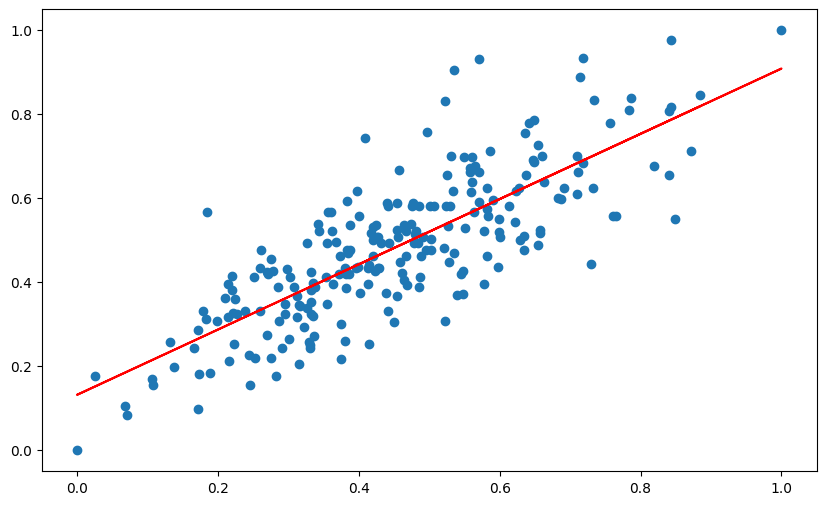

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(x_scaled,y_scaled)
plt.plot(x_scaled,prediction,color="red")
plt.show()